In [ ]:
import os

# Save the current PATH
original_path = os.environ['PATH']

# Set CUDA 12.5 environment variables, appending the original PATH explicitly
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.5'
os.environ['PATH'] = f"/usr/local/cuda-12.5/bin:{original_path}"
os.environ['LD_LIBRARY_PATH'] = f"/usr/local/cuda-12.5/lib64:{os.environ.get('LD_LIBRARY_PATH', '')}"

#!rm -rf /home/ids/yuhe/.cache/torch_extensions


CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/diffusion-AE/'
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()

print('Current working directory is:', '\n', notebook_path)

%load_ext autoreload
%autoreload 2

In [ ]:
import os
import h5py
import torch
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import pandas as pd
from custom_funcs.utils import plot_loss_from_file

In [11]:
import matplotlib.pyplot as plt
import re

def parse_log_file(path):
    """Parse the log file and extract loss values into a dictionary."""
    epochs = []
    loss_bg = []
    loss_t = []
    loss_sbg = []
    total_loss = []

    # Updated regex for your format
    pattern = r"Epoch (\d+)/\d+ \| Validation Loss total_loss: ([\d\.eE+-]+) \| loss_bg: ([\d\.eE+-]+) \| loss_t: ([\d\.eE+-]+) \| loss_sbg: ([\d\.eE+-]+)"

    with open(path, 'r') as f:
        for line in f:
            match = re.search(pattern, line)
            if match:
                epochs.append(int(match.group(1)))
                total_loss.append(float(match.group(2)))
                loss_bg.append(float(match.group(3)))
                loss_t.append(float(match.group(4)))
                loss_sbg.append(float(match.group(5)))

    return {
        'epoch': epochs,
        'loss_bg': loss_bg,
        'loss_t': loss_t,
        'loss_sbg': loss_sbg,
        'total_loss': total_loss
    }

def plot_all_losses(path):
    """Plot all losses on the same figure."""
    data = parse_log_file(path)
    plt.figure(figsize=(10, 6))
    plt.plot(data['epoch'], data['loss_bg'], label='loss_bg')
    plt.plot(data['epoch'], data['loss_t'], label='loss_t')
    plt.plot(data['epoch'], data['loss_sbg'], label='loss_sbg')
    plt.plot(data['epoch'], data['total_loss'], label='total_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('All Validation Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_single_loss(path, loss_name):
    """Plot a single loss curve based on the given loss name."""
    data = parse_log_file(path)
    if loss_name not in data:
        raise ValueError(f"{loss_name} not found. Choose from: loss_bg, loss_t, loss_sbg, total_loss")
    plt.figure(figsize=(10, 5))
    plt.plot(data['epoch'], data[loss_name], label=loss_name)
    plt.xlabel('Epoch')
    plt.ylabel(loss_name)
    plt.title(f'{loss_name} Curve')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


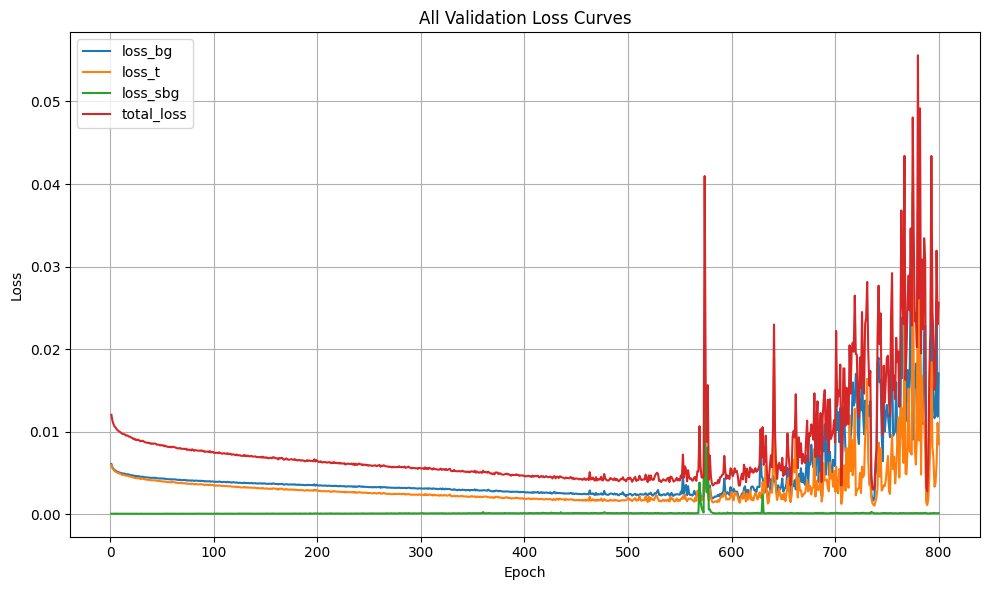

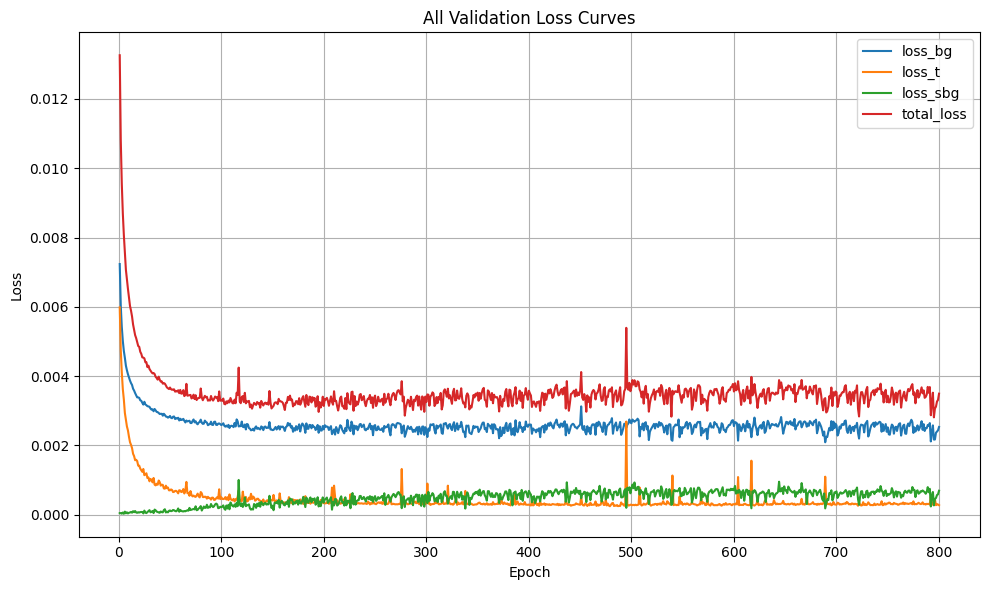

In [15]:
file_path = "results/baseline/lr0.01/logs/val_loss.txt" 
loss_name="loss_t"

plot_all_losses(file_path)
file_path = "results/baseline/lr0.001/logs/val_loss.txt" 
plot_all_losses(file_path)
# plot_single_loss(file_path, loss_name)
